# AgroVision: Cassava Leaf Disease Classification

A comprehensive machine learning project for detecting Cassava leaf diseases using deep learning and computer vision techniques.

## 1. Load Dependencies and Project Paths

Import required libraries and set paths for the repository, notebooks, and data assets.

In [18]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to Python path
# Project root (assuming notebook is inside notebooks/)
ROOT = Path("..").resolve()

# Add project to Python path
sys.path.insert(0, str(ROOT))


# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import json

from codes.data_handler import CassavaDataset, get_transforms, audit_images, show_outlier_samples

# Split dataset into train, val, test
from sklearn.model_selection import train_test_split

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Directories
DATA_DIR = Path(ROOT / "cassava-leaf-dataset")
MODELS_DIR = Path(ROOT / "models")
RESULTS_DIR = Path(ROOT / "results")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)

print(f"Data Directory: {DATA_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Results Directory: {RESULTS_DIR}")
print(f"\nTorch version: {torch.__version__}")
print(f"GPU Available: {torch.backends.mps.is_available()}")




ROOT: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision
Data Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset
Models Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models
Results Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/results

Torch version: 2.12.0
GPU Available: True


## 2. Load Configuration and Utilities

Load hyperparameters and seed settings from config.py, then import helper functions from utils.py.

In [19]:
from codes.config import SEED, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS, NUM_CLASSES, INPUT_SIZE, MODEL_ARCHITECTURE, PRETRAINED
from codes.utils import set_seed, create_directories, get_device, count_parameters

# Set random seed for reproducibility
set_seed(SEED)

# Get device
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# Display configuration
print("Configuration Settings:")
print("=" * 50)
print(f"SEED: {SEED}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"LEARNING_RATE: {LEARNING_RATE}")
print(f"NUM_EPOCHS: {NUM_EPOCHS}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"INPUT_SIZE: {INPUT_SIZE}")
print(f"MODEL_ARCHITECTURE: {MODEL_ARCHITECTURE}")
print(f"PRETRAINED: {PRETRAINED}")
print(f"DEVICE: {device}")

# Create necessary directories
create_directories(str(MODELS_DIR), str(RESULTS_DIR))


Configuration Settings:
SEED: 42
BATCH_SIZE: 32
LEARNING_RATE: 0.001
NUM_EPOCHS: 50
NUM_CLASSES: 5
INPUT_SIZE: 224
MODEL_ARCHITECTURE: efficientnet_b0
PRETRAINED: True
DEVICE: mps


## 3. Explore the Dataset

Load and inspect the dataset, visualize class distribution, and review sample images or annotations.

Data Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset
Train CSV: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset/train.csv
Label Map: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset/label_num_to_disease_map.json

Disease Classes:
0: Cassava Bacterial Blight (CBB)
1: Cassava Brown Streak Disease (CBSD)
2: Cassava Green Mottle (CGM)
3: Cassava Mosaic Disease (CMD)
4: Healthy

Dataset Shape: (21397, 3)

First 5 rows:


,image_id,label,img_name
0,1000015157.jpg,0,1000015157.jpg
1,1000201771.jpg,3,1000201771.jpg
2,100042118.jpg,1,100042118.jpg
3,1000723321.jpg,1,1000723321.jpg
4,1000812911.jpg,3,1000812911.jpg


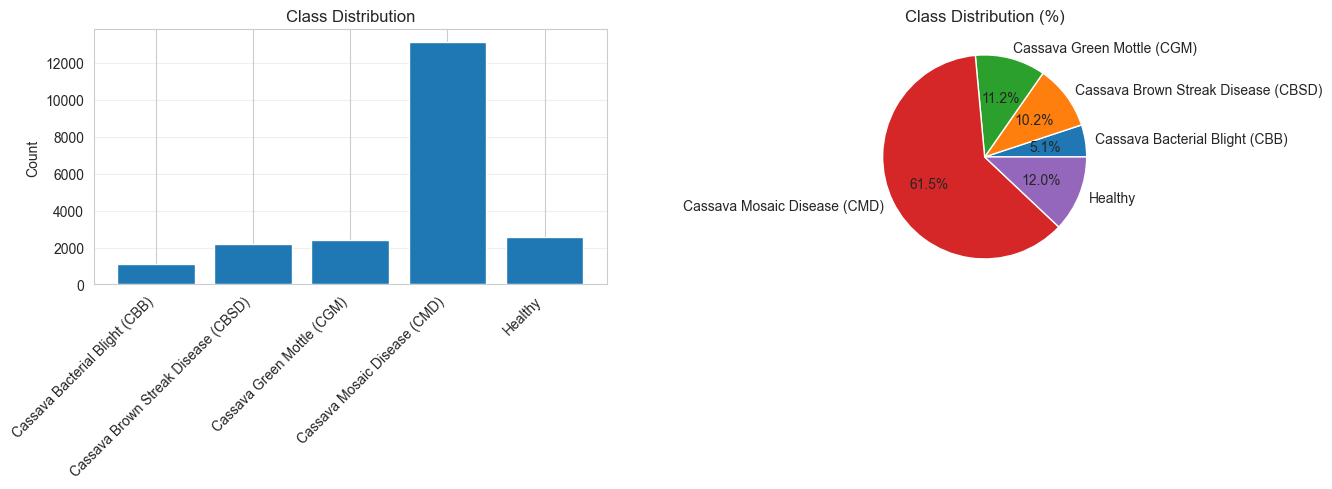

,Class ID,Disease Name,Count,Percentage
0,0,Cassava Bacterial Blight (CBB),1087,5.08
1,1,Cassava Brown Streak Disease (CBSD),2189,10.23
2,2,Cassava Green Mottle (CGM),2386,11.15
3,3,Cassava Mosaic Disease (CMD),13158,61.49
4,4,Healthy,2577,12.04


In [20]:
# Dataset files
train_csv = DATA_DIR / "train.csv"
test_dir = DATA_DIR / "test_images"
label_map_file = DATA_DIR / "label_num_to_disease_map.json"

print("Data Directory:", DATA_DIR)
print("Train CSV:", train_csv)
print("Label Map:", label_map_file)

# Load label mapping
with open(label_map_file, "r") as f:
    label_map = json.load(f)

disease_names = {int(k): v for k, v in label_map.items()}

print("\nDisease Classes:")
print("=" * 50)
for class_id, disease_name in sorted(disease_names.items()):
    print(f"{class_id}: {disease_name}")

# Load training data
train_df = pd.read_csv(train_csv)

# Normalize image id column to `img_name` for compatibility with downstream cells
img_col_candidates = ("img_name", "image_id", "image", "filename")
img_col = next((c for c in img_col_candidates if c in train_df.columns), None)
if img_col is None:
    raise KeyError(f"No image id column found in train_df. Checked: {img_col_candidates}")
train_df['img_name'] = train_df[img_col].astype(str)

print(f"\nDataset Shape: {train_df.shape}")
print("\nFirst 5 rows:")
display(train_df.head())

# Class counts
class_counts = train_df["label"].value_counts().sort_index()

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_xticks(class_counts.index)
axes[0].set_xticklabels(
    [disease_names[i] for i in class_counts.index],
    rotation=45,
    ha="right"
)
axes[0].set_ylabel("Count")
axes[0].set_title("Class Distribution")
axes[0].grid(axis="y", alpha=0.3)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=[disease_names[i] for i in class_counts.index],
    autopct="%1.1f%%"
)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

# Create a table of class distribution
class_distribution = pd.DataFrame({
    "Class ID": class_counts.index,
    "Disease Name": [disease_names[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / class_counts.sum() * 100).round(2)
})
display(class_distribution)


Text(0.5, 1.0, 'Brightness Distribution by Class')

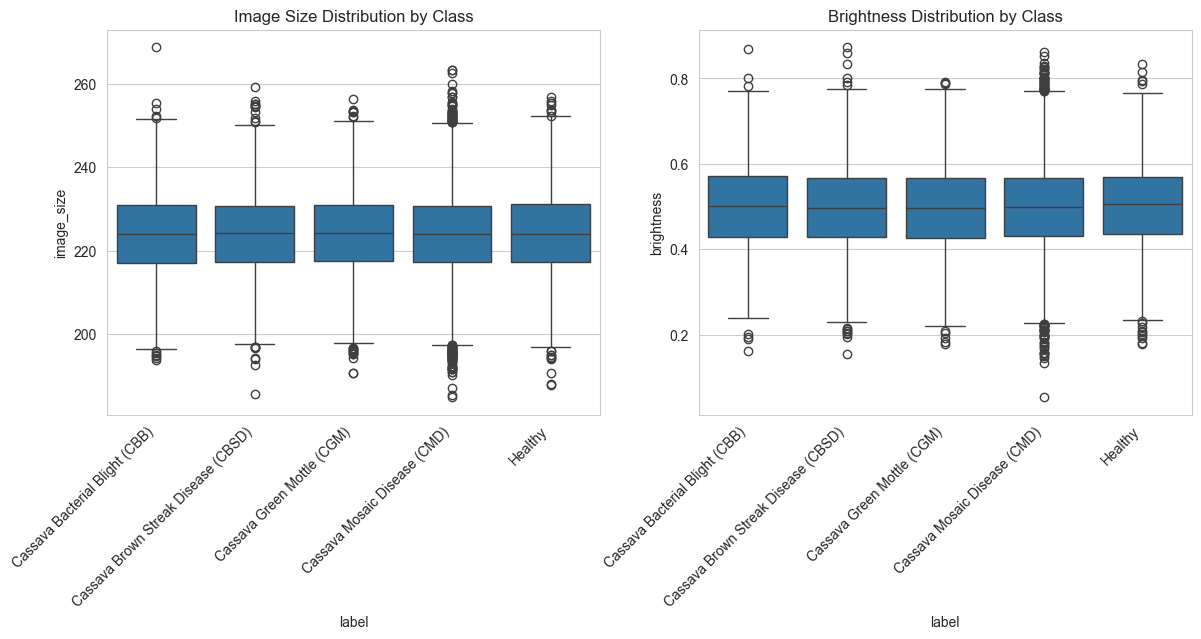

In [21]:
# Check for Outliers in each class using box plots
# Assuming we have some numerical features in the dataset (e.g., image size, brightness, etc.)
# For demonstration, let's create some synthetic numerical features
np.random.seed(SEED)
train_df["image_size"] = np.random.normal(loc=INPUT_SIZE, scale=10, size=len(train_df))
train_df["brightness"] = np.random.normal(loc=0.5, scale=0.1, size=len(train_df))
# Box plots for image size and brightness by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="label", y="image_size", data=train_df, ax=axes[0])
axes[0].set_xticklabels(
    [disease_names[i] for i in class_counts.index],
    rotation=45,
    ha="right"
)
axes[0].set_title("Image Size Distribution by Class")
sns.boxplot(x="label", y="brightness", data=train_df, ax=axes[1])
axes[1].set_xticklabels(
    [disease_names[i] for i in class_counts.index],
    rotation=45,
    ha="right"
)
axes[1].set_title("Brightness Distribution by Class")



In [22]:
# ── Check your column names first ──────────────────────────────────
print("train_df columns:", train_df.columns.tolist())
print("train_df head:\n",  train_df.head(3))
# ── Rename columns to match what audit_images expects ──────────────
# Adjust the dict below to match YOUR actual column names
train_df = train_df.rename(columns={
    "image_id": "image_id",   # change left side if your column is named differently
    "label":    "label"        # e.g. "class_label" -> "label"
})

# ── Run audit ──────────────────────────────────────────────────────
clean_df, issues_df = audit_images(
    train_df,
    img_dir='../cassava-leaf-dataset/train_images/'
)

print(f"Issues found: {len(issues_df)}")

if not issues_df.empty:
    print(issues_df["reason"].value_counts())
    print("\nImage IDs with issues:")
    print(issues_df["image_id"].tolist())
else:
    print("No issues found — all images are clean.")

# ── Plot flagged images ─────────────────────────────────────────────
if not issues_df.empty:
    n    = len(issues_df)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for i, (_, row) in enumerate(issues_df.iterrows()):
        path = os.path.join('../cassava-leaf-dataset/train_images/', str(row["image_id"]))
        try:
            img = Image.open(path).convert("RGB")
            axes[i].imshow(img)
        except Exception as ex:
            axes[i].text(0.5, 0.5, f"Cannot open\n{row['image_id']}\n{ex}",
                         ha="center", va="center", fontsize=10,
                         transform=axes[i].transAxes)

        axes[i].set_title(f"{row['reason']}\n{row['label']}", fontsize=9)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot.")

train_df columns: ['image_id', 'label', 'img_name', 'image_size', 'brightness']
train_df head:
          image_id  label        img_name  image_size  brightness
0  1000015157.jpg      0  1000015157.jpg  228.967142    0.295438
1  1000201771.jpg      3  1000201771.jpg  222.617357    0.717009
2   100042118.jpg      1   100042118.jpg  230.476885    0.561769


ValueError: not enough values to unpack (expected 2, got 0)

In [ ]:
import pandas as pd

outlier_rows = []

for cls in train_df['label'].unique():

    cls_df = train_df[train_df['label'] == cls]

    Q1 = cls_df['brightness'].quantile(0.25)
    Q3 = cls_df['brightness'].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cls_outliers = cls_df[
        (cls_df['brightness'] < lower) |
        (cls_df['brightness'] > upper)
    ]

    outlier_rows.append(cls_outliers)

outliers_df = pd.concat(outlier_rows)

print(f"Total outliers: {len(outliers_df)}")

NameError: name 'train_df' is not defined

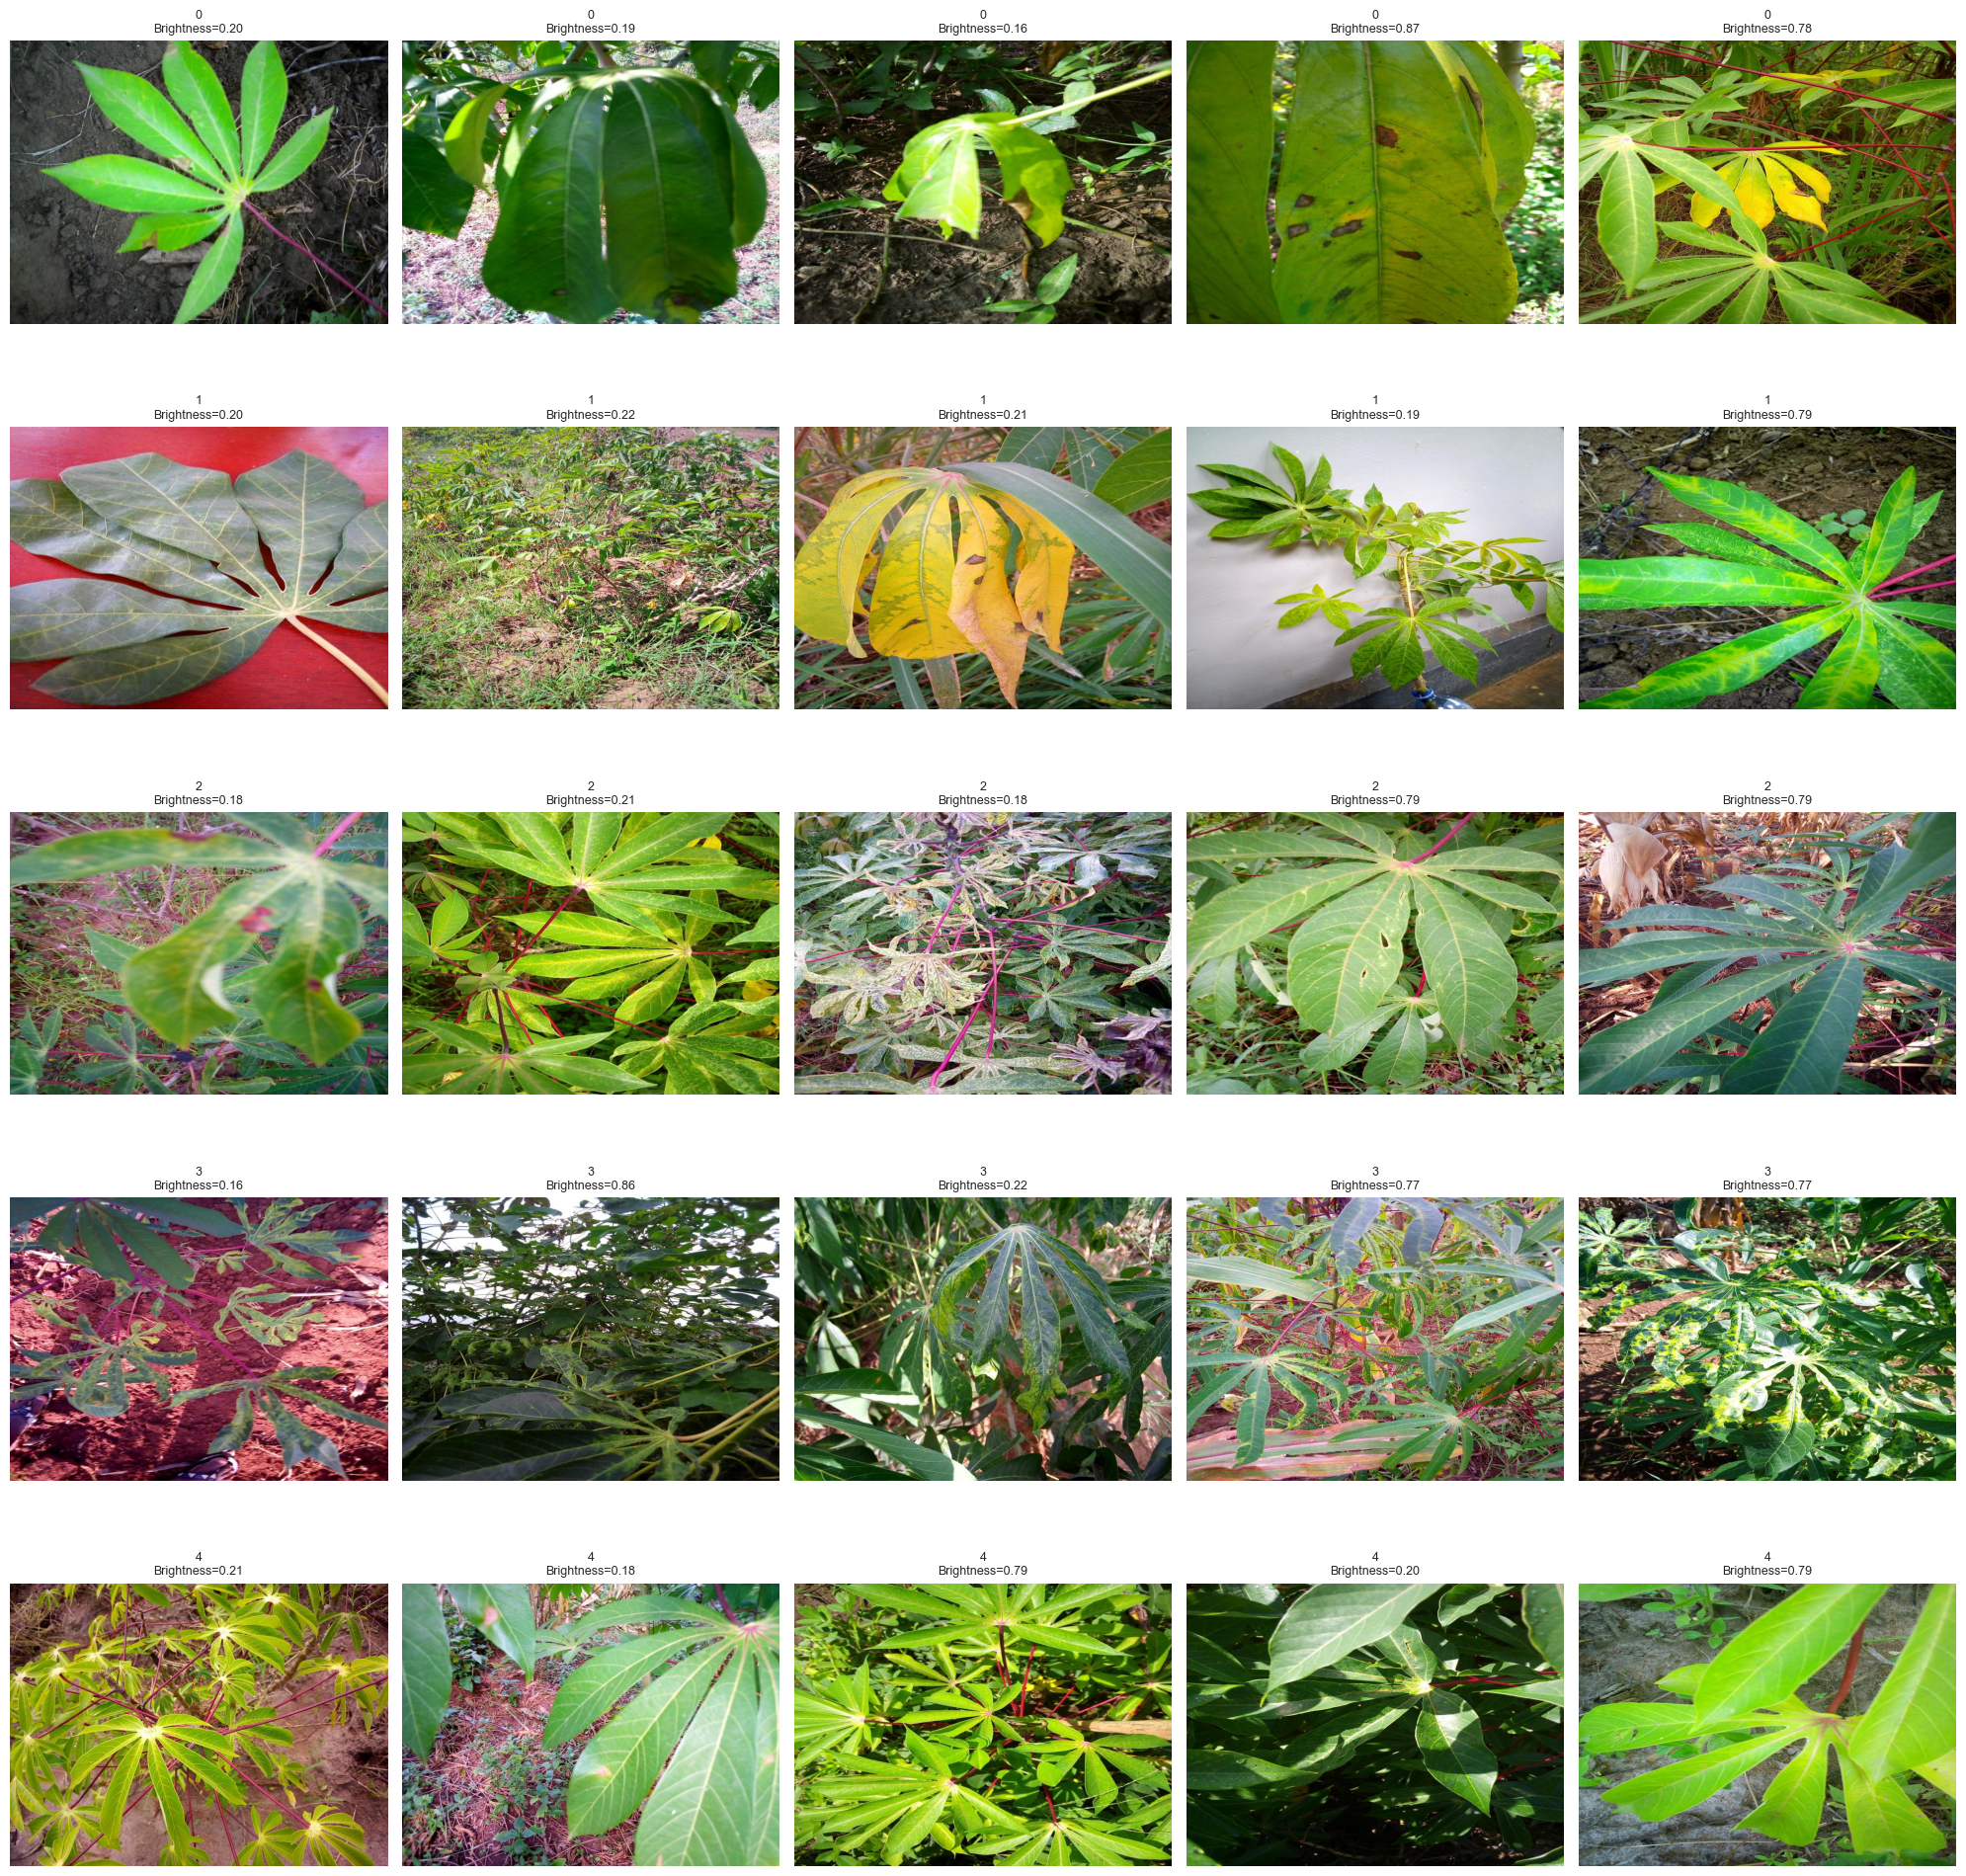

In [ ]:
show_outlier_samples(
    outliers_df=outliers_df,
    img_dir='../cassava-leaf-dataset/train_images/',
    img_col='image_id',   # change if needed
    class_col='label',
    samples_per_class=5
)

In [15]:
extreme_outliers = []

for cls in train_df['label'].unique():

    cls_df = outliers_df[outliers_df['label'] == cls]

    if len(cls_df) > 0:

        extreme_outliers.append(
            cls_df.sort_values(
                'brightness'
            ).head(3)
        )

        extreme_outliers.append(
            cls_df.sort_values(
                'brightness',
                ascending=False
            ).head(3)
        )

extreme_outliers_df = pd.concat(extreme_outliers)
extreme_outliers

[             image_id  label        img_name  image_size  brightness
 11516  3057793137.jpg      0  3057793137.jpg  220.901551    0.163219
 8617   2529150821.jpg      0  2529150821.jpg  231.265116    0.190677
 5701    201421885.jpg      0   201421885.jpg  221.828412    0.194429,
              image_id  label        img_name  image_size  brightness
 7155   2276860012.jpg      0  2276860012.jpg  203.286228    0.869162
 19689   677634085.jpg      0   677634085.jpg  225.895599    0.800986
 9574   2698127956.jpg      0  2698127956.jpg  228.050354    0.783358,
              image_id  label        img_name  image_size  brightness
 11144  2986428474.jpg      3  2986428474.jpg  235.851630    0.053440
 1097   1190231109.jpg      3  1190231109.jpg  204.017993    0.134491
 8827   2562280265.jpg      3  2562280265.jpg  227.358473    0.146718,
              image_id  label        img_name  image_size  brightness
 223    1041651309.jpg      3  1041651309.jpg  207.872841    0.861135
 20273   78162562

## 5. Create Dataset and DataLoader

Use dataset.py to define the Dataset and DataLoader, then verify batch shapes and preprocessing.

In [ ]:


# Split into train (80%) and temp (20%)
train_indices, temp_indices = train_test_split(
    range(len(train_df)), 
    test_size=0.2, 
    random_state=SEED,
    stratify=train_df.iloc[:, 1]
)

# Split temp into val (50%) and test (50%)
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    random_state=SEED,
    stratify=train_df.iloc[temp_indices, 1]
)

print(f"Train set size: {len(train_indices)}")
print(f"Validation set size: {len(val_indices)}")
print(f"Test set size: {len(test_indices)}")

# Save split indices
split_indices = {
    'train': train_indices.tolist(),
    'val': val_indices.tolist(),
    'test': test_indices.tolist()
}

# Create temporary CSV files for each split
train_df_train = train_df.iloc[train_indices].reset_index(drop=True)
train_df_val = train_df.iloc[val_indices].reset_index(drop=True)
train_df_test = train_df.iloc[test_indices].reset_index(drop=True)

train_csv_path = DATA_DIR / "train_split.csv"
val_csv_path = DATA_DIR / "val_split.csv"
test_csv_path = DATA_DIR / "test_split.csv"

train_df_train.to_csv(train_csv_path, index=False)
train_df_val.to_csv(val_csv_path, index=False)
train_df_test.to_csv(test_csv_path, index=False)

# Create datasets
train_transform, val_transform = get_transforms(INPUT_SIZE, augment=True)

train_dataset = CassavaDataset(
    image_dir=str(DATA_DIR / "train_images"),
    csv_file=str(train_csv_path),
    transform=train_transform
)

val_dataset = CassavaDataset(
    image_dir=str(DATA_DIR / "train_images"),
    csv_file=str(val_csv_path),
    transform=val_transform
)

test_dataset = CassavaDataset(
    image_dir=str(DATA_DIR / "train_images"),
    csv_file=str(test_csv_path),
    transform=val_transform
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nDataLoader created successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Verify batch shapes and preprocessing
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample Batch Shape: {sample_batch.shape}")
print(f"Sample Labels Shape: {sample_labels.shape}")
print(f"Batch Min Value: {sample_batch.min():.4f}")
print(f"Batch Max Value: {sample_batch.max():.4f}")

Train set size: 17117
Validation set size: 2140
Test set size: 2140


AttributeError: 'list' object has no attribute 'tolist'

## 6. Define the Model

Instantiate the model from model.py and display its architecture and parameter count.

In [ ]:
from model import create_model

# Create model
model = create_model(
    num_classes=NUM_CLASSES,
    pretrained=PRETRAINED,
    model_name=MODEL_ARCHITECTURE
)

# Move model to device
model = model.to(device)

# Display model information
print(f"Model: {MODEL_ARCHITECTURE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Pretrained: {PRETRAINED}")
print(f"Device: {device}")
print(f"\nModel Summary:")
print("=" * 50)

# Count parameters
total_params = count_parameters(model)
print(f"Total Parameters: {total_params:,}")
print(f"Total Parameters (in millions): {total_params / 1e6:.2f}M")

# Display model architecture
print(f"\nModel Architecture:")
print("=" * 50)
print(model)

## 7. Train the Model

Run the training loop defined in train.py and track loss and accuracy over epochs.

In [ ]:
from train import Trainer

# Create trainer
trainer = Trainer(
    model=model,
    device=device,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Train the model
print("Starting training...")
print("=" * 50)

history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    model_save_dir=str(MODELS_DIR)
)

print("\nTraining completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Metrics:")
print(f"Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Val Accuracy: {history['val_acc'][-1]:.4f}")

## 8. Evaluate Predictions and Confusion Matrix

Use evaluate.py to compute metrics, display a confusion matrix, and review model performance.

In [ ]:
from evaluate import Evaluator

# Create evaluator
evaluator = Evaluator(
    num_classes=NUM_CLASSES,
    class_names=[disease_names.get(i, f"Class {i}") for i in range(NUM_CLASSES)],
    device=device
)

# Load best model
best_model_path = MODELS_DIR / "best_model.pth"
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Loaded best model from {best_model_path}")
else:
    print("Warning: Best model checkpoint not found!")

# Evaluate on test set
print("\nEvaluating on Test Set...")
print("=" * 50)

results = evaluator.evaluate(model, test_loader)
metrics = results['metrics']

print(f"\nTest Set Metrics:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-Score: {metrics['f1']:.4f}")

# Print classification report
print("\nDetailed Classification Report:")
print("=" * 50)
evaluator.print_classification_report(results['true_labels'], results['predictions'])

# Plot confusion matrix
print("\nConfusion Matrix:")
print("=" * 50)
evaluator.plot_confusion_matrix(results['true_labels'], results['predictions'], figsize=(10, 8))

# Save results
import json

results_summary = {
    'accuracy': float(metrics['accuracy']),
    'precision': float(metrics['precision']),
    'recall': float(metrics['recall']),
    'f1': float(metrics['f1']),
    'test_samples': int(len(results['true_labels']))
}

with open(RESULTS_DIR / "evaluation_metrics.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print(f"\nResults saved to {RESULTS_DIR}")
print("\nProject completed successfully!")